<a href="https://colab.research.google.com/github/Ameeghai/Quantum-RNG-Hybrid/blob/main/noise_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install qiskit

In [23]:
!pip install qiskit_aer

In [24]:
!pip install pylatexenc


Example random number generated: 4023759979
Shannon entropy: 12.2877 bits (max = 32)
Min-entropy: 12.2877 bits


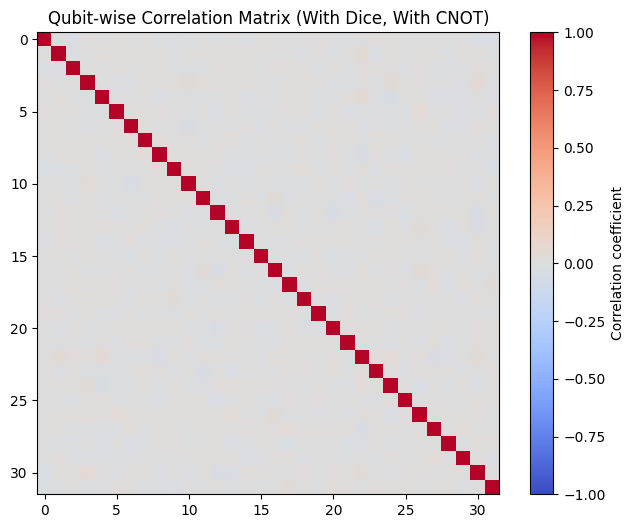

Average off-diagonal correlation = 0.0114

First 20 measurement sequences (shots):
[[1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0]
 [0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1]
 [0 0 1 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 0 0]
 [1 1 0 1 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0]
 [1 0 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0]
 [0 0 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1]
 [1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 1 1 0 0 1 0 0 1 1]
 [0 1 1 0 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 1 1]
 [1 1 0 0 1 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0]
 [0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1]
 [1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0 1 1]
 [0 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1]
 [1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 

In [25]:
# Hybrid QRNG: 32-bit, With Dice, With CNOT (5000 shots)
import numpy as np
from math import log2
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

# ----------------------------
# Step 1: Shot-Noise
def generate_shot_noise_bits(length=32):
    return np.random.choice([0, 1], size=length, p=[0.5, 0.5])

shot_noise_bits = generate_shot_noise_bits(32)

# ----------------------------
# Step 2: Quantum Circuit
qc = QuantumCircuit(32, 32)
for i, bit in enumerate(shot_noise_bits):
    if bit == 1:
        qc.x(i)

# ----------------------------
# Step 3: Hadamard
for q in range(32):
    qc.h(q)

# ----------------------------
# Step 4: Dice for Random CNOT Pairs
def dice_pairs(num_qubits=32):
    available = list(range(num_qubits))
    pairs = []
    while len(available) >= 2:
        d1, d2 = random.sample(available, 2)
        pairs.append((d1, d2))
        available.remove(d1)
        available.remove(d2)
    return pairs

pairs = dice_pairs(32)
for ctrl, tgt in pairs:
    qc.cx(ctrl, tgt)

# Dice measurement order
def dice_measurement_order(num_qubits=32):
    available = list(range(num_qubits))
    order = []
    while available:
        choice = random.choice(available)
        order.append(choice)
        available.remove(choice)
    return order

measurement_order = dice_measurement_order(32)
for idx, q in enumerate(measurement_order):
    qc.measure(q, idx)

# ----------------------------
# Step 5: Run Simulation
simulator = AerSimulator()
result = simulator.run(qc, shots=5000).result()
counts = result.get_counts()

# ----------------------------
# Step 6: Random Number, Entropy, Correlation
outcomes = list(counts.keys())
probabilities = np.array(list(counts.values())) / sum(list(counts.values()))
measured_bits = np.random.choice(outcomes, p=probabilities)
random_number = int(measured_bits, 2)
print(f"Example random number generated: {random_number}")

entropy = -np.sum([p*log2(p) for p in probabilities if p>0])
min_entropy = -log2(np.max(probabilities))
print(f"Shannon entropy: {entropy:.4f} bits (max = 32)")
print(f"Min-entropy: {min_entropy:.4f} bits")

bit_matrix = np.array([list(map(int, o)) for o in np.repeat(outcomes, list(counts.values()), axis=0)])
correlation_matrix = np.corrcoef(bit_matrix.T)
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation coefficient')
plt.title("Qubit-wise Correlation Matrix (With Dice, With CNOT)")
plt.show()

num_qubits = correlation_matrix.shape[0]
avg_off_diag_corr = (np.sum(np.abs(correlation_matrix)) - num_qubits) / (num_qubits*(num_qubits-1))
print(f"Average off-diagonal correlation = {avg_off_diag_corr:.4f}")

print("\nFirst 20 measurement sequences (shots):")
print(bit_matrix[:20])


In [26]:
import numpy as np
from math import log2
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

In [27]:
def compute_bitwise_entropy(counts):
    outcomes = list(counts.keys())
    counts_list = list(counts.values())

    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, counts_list, axis=0)
    ])

    entropies = []

    for i in range(32):
        col = bit_matrix[:, i]
        p1 = np.mean(col)
        p0 = 1 - p1

        if p0 > 0 and p1 > 0:
            h = -(p0*log2(p0) + p1*log2(p1))
        else:
            h = 0

        entropies.append(h)

    avg_entropy = np.mean(entropies)

    return avg_entropy, avg_entropy*32

In [28]:
# Layer 1

num_samples = 1000
num_bits = 32

data = np.random.choice([0,1], size=(num_samples, num_bits), p=[0.5,0.5])

entropies = []
for i in range(num_bits):
    col = data[:, i]
    p1 = np.mean(col)
    p0 = 1 - p1
    h = -(p0*log2(p0) + p1*log2(p1))
    entropies.append(h)

print("Layer 1 Avg entropy:", np.mean(entropies))

Layer 1 Avg entropy: 0.9991417055905429


In [29]:
# Layer 2

bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

p_init = 0.05
flip_mask = np.random.rand(32) < p_init
bits = np.logical_xor(bits, flip_mask).astype(int)

p1 = np.mean(bits)
p0 = 1 - p1

entropy = -(p0*log2(p0) + p1*log2(p1))

print("Layer 2 entropy:", entropy)

Layer 2 entropy: 0.9971803988942642


In [30]:
# Layer 3

qc = QuantumCircuit(32, 32)

for i, bit in enumerate(bits):
    if bit == 1:
        qc.x(i)

for i in range(32):
    qc.h(i)

available = list(range(32))
while len(available) >= 2:
    a, b = random.sample(available, 2)
    qc.cx(a, b)
    available.remove(a)
    available.remove(b)

for i in range(32):
    qc.measure(i, i)

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()

avg_h, total_h = compute_bitwise_entropy(counts)

print("Layer 3 Avg entropy:", avg_h)
print("Layer 3 Total entropy:", total_h)

Layer 3 Avg entropy: 0.9998113521875223
Layer 3 Total entropy: 31.993963270000712


In [31]:
# Layer 4

def apply_measurement_noise(counts, p_meas=0.02):
    new_counts = {}
    for bitstring, count in counts.items():
        for _ in range(count):
            bits = list(bitstring)
            for i in range(len(bits)):
                if np.random.rand() < p_meas:
                    bits[i] = '1' if bits[i]=='0' else '0'
            new_str = ''.join(bits)
            new_counts[new_str] = new_counts.get(new_str, 0) + 1
    return new_counts

counts_noisy = apply_measurement_noise(counts, p_meas=0.02)

avg_h, total_h = compute_bitwise_entropy(counts_noisy)

print("Layer 4 Avg entropy:", avg_h)
print("Layer 4 Total entropy:", total_h)

Layer 4 Avg entropy: 0.999824806875721
Layer 4 Total entropy: 31.99439382002307


Layer 5 Avg correlation: 0.011487583916930761


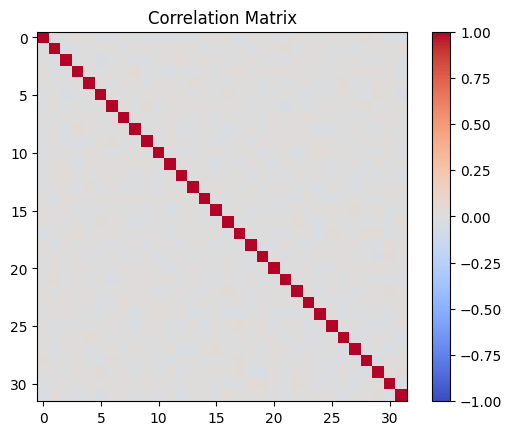

In [32]:
# Layer 5

outcomes = list(counts_noisy.keys())
counts_list = list(counts_noisy.values())

bit_matrix = np.array([
    list(map(int, o))
    for o in np.repeat(outcomes, counts_list, axis=0)
])

corr = np.corrcoef(bit_matrix.T)

avg_corr = (np.sum(np.abs(corr)) - 32) / (32*31)

print("Layer 5 Avg correlation:", avg_corr)

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [33]:
# FULL PIPELINE

# Layer 1
bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

# Layer 2
p_init = 0.02
flip_mask = np.random.rand(32) < p_init
bits = np.logical_xor(bits, flip_mask).astype(int)

# Layer 3
qc = QuantumCircuit(32, 32)

for i, bit in enumerate(bits):
    if bit == 1:
        qc.x(i)

for i in range(32):
    qc.h(i)

available = list(range(32))
while len(available) >= 2:
    a, b = random.sample(available, 2)
    qc.cx(a, b)
    available.remove(a)
    available.remove(b)

for i in range(32):
    qc.measure(i, i)

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()

# ----------------------------
# Layer 4: Measurement Noise
counts = apply_measurement_noise(counts, p_meas=0.02)

# ----------------------------
# Layer 5: ANALYSIS

# ---- Bit-wise entropy (already done)
avg_h, total_h = compute_bitwise_entropy(counts)

# ---- Shannon entropy (full 32-bit strings)
outcomes = list(counts.keys())
probs = np.array(list(counts.values())) / sum(counts.values())

shannon_entropy = -np.sum([p * log2(p) for p in probs if p > 0])

# ---- Build bit matrix for correlation
bit_matrix = np.array([
    list(map(int, o))
    for o in np.repeat(outcomes, list(counts.values()), axis=0)
])

# ---- Correlation matrix
corr_matrix = np.corrcoef(bit_matrix.T)

num_qubits = corr_matrix.shape[0]

# Average off-diagonal correlation
avg_off_diag_corr = (
    np.sum(np.abs(corr_matrix)) - num_qubits
) / (num_qubits * (num_qubits - 1))

# ----------------------------
# PRINT RESULTS

print("Final Avg entropy per bit:", avg_h)
print("Final Total entropy (~32 bits):", total_h)

print("Shannon entropy (full strings):", shannon_entropy)

print("Average off-diagonal correlation:", avg_off_diag_corr)

Final Avg entropy per bit: 0.9998598401188864
Final Total entropy (~32 bits): 31.995514883804365
Shannon entropy (full strings): 12.287712379549447
Average off-diagonal correlation: 0.011141756065050978


In [34]:
# ----------------------------
# FUNCTION TO RUN PIPELINE

def run_pipeline(p_init=0, p_meas=0):

    # Layer 1
    bits = np.random.choice([0,1], size=32, p=[0.5,0.5])

    # Layer 2
    flip_mask = np.random.rand(32) < p_init
    bits = np.logical_xor(bits, flip_mask).astype(int)

    # Layer 3
    qc = QuantumCircuit(32, 32)

    for i, bit in enumerate(bits):
        if bit == 1:
            qc.x(i)

    for i in range(32):
        qc.h(i)

    available = list(range(32))
    while len(available) >= 2:
        a, b = random.sample(available, 2)
        qc.cx(a, b)
        available.remove(a)
        available.remove(b)

    for i in range(32):
        qc.measure(i, i)

    sim = AerSimulator()
    result = sim.run(qc, shots=5000).result()
    counts = result.get_counts()

    # Measurement noise
    if p_meas > 0:
        counts = apply_measurement_noise(counts, p_meas)

    # ----------------------------
    # ANALYSIS

    outcomes = list(counts.keys())
    probs = np.array(list(counts.values())) / sum(counts.values())

    # Shannon entropy
    shannon = -np.sum([p*log2(p) for p in probs if p > 0])

    # Min entropy
    min_entropy = -log2(np.max(probs))

    # Bit-wise entropy
    avg_h, total_h = compute_bitwise_entropy(counts)

    # Correlation
    bit_matrix = np.array([
        list(map(int, o))
        for o in np.repeat(outcomes, list(counts.values()), axis=0)
    ])

    corr = np.corrcoef(bit_matrix.T)
    num_q = corr.shape[0]

    avg_corr = (np.sum(np.abs(corr)) - num_q) / (num_q*(num_q-1))

    return {
        "avg_bit_entropy": avg_h,
        "total_entropy": total_h,
        "shannon_entropy": shannon,
        "min_entropy": min_entropy,
        "correlation": avg_corr
    }

# ----------------------------
# RUN BOTH CASES

no_noise = run_pipeline(p_init=0, p_meas=0)
with_noise = run_pipeline(p_init=0.02, p_meas=0.02)

# ----------------------------
# PRINT COMPARISON

print("\n--- WITHOUT NOISE ---")
for k, v in no_noise.items():
    print(f"{k}: {v}")

print("\n--- WITH NOISE ---")
for k, v in with_noise.items():
    print(f"{k}: {v}")


--- WITHOUT NOISE ---
avg_bit_entropy: 0.999866577616373
total_entropy: 31.995730483723936
shannon_entropy: 12.287712379549447
min_entropy: 12.287712379549449
correlation: 0.011767071796908952

--- WITH NOISE ---
avg_bit_entropy: 0.9998135559751895
total_entropy: 31.994033791206064
shannon_entropy: 12.287712379549447
min_entropy: 12.287712379549449
correlation: 0.01123037970701409
